In [ ]:
# %%
# RAG Chunking + Embedding Evaluation — compact, DRY, Jupyter-first

import math
from pathlib import Path
import re
import subprocess
from textwrap import dedent

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

sns.set_context("talk")
sns.set_style("whitegrid")

print("✅ Imports & styling ready.")


✅ Imports & styling ready.


In [36]:
# %%
# --- Config (edit as needed) ---
CSV_PATH = "../artifacts/loss.csv"     # evaluator CSV path
OUT_DIR = Path("../artifacts/figs")    # output directory
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Defaults for metrics
K_DEFAULT = 10
BETA = 2.0    # weight recall in RRF@k
ALPHA = 2.0   # recall exponent for RRF-G
GAMMA = 1.0   # nDCG exponent for RRF-G
DELTA = 0.5   # MRR exponent for RRF-G

# Common plot tunables
HEATMAP_CMAP = "RdYlGn"
TOPN_CURVES = 5
CHUNK_SIZES = [128, 256, 384, 448]
OVERLAPS = [0, 16, 32, 64]

print(f"CSV_PATH = {CSV_PATH}")
print(f"OUT_DIR  = {OUT_DIR.resolve()}")


CSV_PATH = ../artifacts/loss.csv
OUT_DIR  = /home/chunk_twice_embed_once/artifacts/figs


In [37]:
# %%
# ---------- Utilities: IO / columns / metrics / labels / saving ----------

def _safe_num(s):
    return pd.to_numeric(s, errors="coerce")

def harmonize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rename = {}
    at_k_regex = re.compile(r'^(?P<base>[A-Za-z\-]+)@(?P<k>\d+|k)$')

    for c in list(df.columns):
        cs = c.strip()
        m = at_k_regex.match(cs)
        if not m:
            continue
        base = m.group("base").lower()
        kval = m.group("k")

        def mk(base_name: str) -> str:
            return f"{base_name}_at_k" if kval == "k" else f"{base_name}_at_{kval}"

        if base in ("ndcg", "recall", "map", "mrr"):
            new_c = mk(base)
        elif base in ("precision", "p"):
            new_c = mk("precision")
        elif base in ("rrf", "rrf-beta", "rrfβ"):
            new_c = "rrf_beta_at_k"
        elif base in ("rrf-g", "rrfg", "rrf_g"):
            new_c = "rrf_g_at_k"
        else:
            continue

        rename[c] = new_c

    df = df.rename(columns=rename)

    # determine k for *_at_k → *_at_<k>
    k_series = next((df[col] for col in ("k_req", "k_request") if col in df.columns), None)
    k_used = int(_safe_num(k_series.dropna().iloc[0])) if k_series is not None and pd.notna(k_series).any() else K_DEFAULT

    for base in ("ndcg", "recall", "map", "mrr", "precision"):
        generic = f"{base}_at_k"
        specific = f"{base}_at_{k_used}"
        if generic in df.columns and specific not in df.columns:
            df[specific] = _safe_num(df[generic])

    if 'model_short' not in df.columns and 'model_name' in df.columns:
        df['model_short'] = df['model_name'].astype(str).str.replace(r'[_\-]+', ' ', regex=True)

    for c in ('token_size','overlap','cost_norm'):
        if c in df.columns:
            df[c] = _safe_num(df[c])
    if 'cost_norm' not in df.columns:
        df['cost_norm'] = 1.0

    # drop duplicate column names if any
    if pd.Series(df.columns).duplicated().any():
        df = df.loc[:, ~pd.Series(df.columns).duplicated()].copy()

    return df

_K_REGEX = re.compile(r"^(?P<base>ndcg|recall|map|mrr)_at_(?P<k>\d+)$")

def _nearest_k_available(df: pd.DataFrame, base: str, k: int):
    cands = [(c, int(m.group("k"))) for c in df.columns if (m := _K_REGEX.match(c)) and m.group("base")==base]
    if not cands:
        return (None, None)
    return min(cands, key=lambda t: abs(t[1]-k))

def _get_metric_series(df: pd.DataFrame, base: str, k: int):
    exact = f"{base}_at_{k}"
    if exact in df.columns:
        return (_safe_num(df[exact]), k, exact, None)
    col, used_k = _nearest_k_available(df, base, k)
    if col is None:
        return (pd.Series([np.nan]*len(df), index=df.index), None, None,
                f"Missing {base}@{k} and no {base}_at_* columns found.")
    warn = None if used_k==k else f"Missing {base}_at_{k}; using {base}_at_{used_k} instead."
    return (_safe_num(df[col]), used_k, col, warn)

def rrf_beta(recall, ndcg, beta=BETA):
    r = np.clip(_safe_num(recall).to_numpy(), 0, None)
    n = np.clip(_safe_num(ndcg).to_numpy(), 0, None)
    b2 = float(beta)**2
    num = (1 + b2) * r * n
    den = (b2 * n + r)
    out = np.divide(num, den, out=np.zeros_like(num), where=(den>0) & (r>0) & (n>0))
    return pd.Series(out)

def rrf_g(recall, ndcg, mrr=None, alpha=ALPHA, gamma=GAMMA, delta=DELTA):
    r = np.clip(_safe_num(recall).to_numpy(), 0, None)
    n = np.clip(_safe_num(ndcg).to_numpy(), 0, None)
    mask_req = (r>0) & (n>0)
    out = np.zeros_like(r, dtype=float)
    if mrr is None:
        prod = (np.power(r, alpha) * np.power(n, gamma))
        power = 1.0 / (alpha + gamma)
        with np.errstate(invalid='ignore'):
            out[mask_req] = np.power(prod[mask_req], power)
    else:
        m = np.clip(_safe_num(mrr).to_numpy(), 0, None)
        mask = mask_req & (m>0)
        prod = (np.power(r, alpha) * np.power(n, gamma) * np.power(m, delta))
        power = 1.0 / (alpha + gamma + delta)
        with np.errstate(invalid='ignore'):
            out[mask] = np.power(prod[mask], power)
    return pd.Series(out)

def ensure_cols(df: pd.DataFrame, k=K_DEFAULT, beta=BETA, alpha=ALPHA, gamma=GAMMA, delta=DELTA):
    df = df.copy()

    # Keep/ensure conveniences
    if 'chunker' in df.columns:
        df['chunker'] = df['chunker'].fillna('unknown')
    if 'model_name' in df.columns and 'model_short' not in df.columns:
        df['model_short'] = df['model_name'].astype(str).str.replace(r'[_\-]+', ' ', regex=True)
    for c in ['token_size','overlap']:
        if c in df: df[c] = _safe_num(df[c])
    if 'cost_norm' not in df.columns:
        df['cost_norm'] = 1.0

    warns = []
    rec_s, k_rec, _, w = _get_metric_series(df, "recall", k);  warns += [w] if w else []
    ndc_s, k_ndc, _, w = _get_metric_series(df, "ndcg",   k);  warns += [w] if w else []
    map_s, k_map, _, w = _get_metric_series(df, "map",    k);  warns += [w] if w else []
    mrr_s, k_mrr, _, w = _get_metric_series(df, "mrr",    k);  warns += [w] if w else []

    df['recall_at_k'] = rec_s
    df['ndcg_at_k']   = ndc_s
    df['map_at_k']    = map_s
    df['mrr_at_k']    = mrr_s

    if 'rrf_beta_at_k' not in df:
        df['rrf_beta_at_k'] = rrf_beta(df['recall_at_k'], df['ndcg_at_k'], beta=beta)
    if 'rrf_g_at_k' not in df:
        df['rrf_g_at_k']    = rrf_g(df['recall_at_k'], df['ndcg_at_k'], df['mrr_at_k'],
                                    alpha=alpha, gamma=gamma, delta=delta)

    df['k_request']     = k
    df['k_recall_used'] = k_rec
    df['k_ndcg_used']   = k_ndc
    df['k_map_used']    = k_map
    df['k_mrr_used']    = k_mrr
    df['beta']          = beta
    df['alpha']         = alpha
    df['gamma']         = gamma
    df['delta']         = delta

    for msg in sorted(set([m for m in warns if m])):
        print("⚠️", msg)
    return df

def pick_metric(df: pd.DataFrame, prefs=("rrf_beta_at_k", "rrf_g_at_k", "ndcg_at_k")):
    for m in prefs:
        if m in df.columns: return m
    raise ValueError(f"No metric columns found among {prefs}. Run ensure_cols() first.")

PRETTY = {
    "rrf_beta_at_k": "RRF@k",
    "rrf_g_at_k":    "RRF-G@k",
    "ndcg_at_k":     "nDCG@k",
}

def metric_title(df, metric_col):
    parts = [PRETTY.get(metric_col, metric_col)]
    if "k_request" in df and df["k_request"].notna().any():
        parts.append(f"k={int(df['k_request'].dropna().iloc[0])}")
    if metric_col=="rrf_beta_at_k" and "beta" in df and df["beta"].notna().any():
        try:
            parts.append(f"β={df['beta'].dropna().iloc[0]:g}")
        except Exception:
            parts.append(f"β={df['beta'].dropna().iloc[0]}")
    return " • ".join(parts)

def savefig(fig, name_base: str):
    png = OUT_DIR / f"{name_base}.png"
    pdf = OUT_DIR / f"{name_base}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, dpi=300, bbox_inches="tight")
    print(f"✅ Saved: {png.name} | {pdf.name}")

def pareto_frontier(df, x='cost_norm', y='rrf_beta_at_k', minimize_x=True, maximize_y=True):
    X = df[x].to_numpy()
    Y = df[y].to_numpy()
    order = np.lexsort((-Y, X)) if (minimize_x and maximize_y) else np.argsort(X)
    best_y = -math.inf
    mask = np.zeros(len(df), dtype=bool)
    for idx in order:
        yi = Y[idx]
        if yi > best_y + 1e-12:
            mask[idx] = True
            best_y = yi
    return mask

def latex_table(df, caption, label, floatfmt="{:.3f}", bold_cols=()):
    df2 = df.copy()
    for col in bold_cols:
        if col in df2:
            if df2[col].dtype.kind in "fiu":
                best = df2[col].max()
            else:
                best = None
            def fmt_bold(v):
                s = floatfmt.format(v) if isinstance(v, (float,int,np.floating,np.integer)) else str(v)
                return r"\textbf{" + s + "}" if best is not None and v == best else s
            df2[col] = df2[col].apply(fmt_bold)

    for col in df2.columns:
        if col in bold_cols: continue
        if pd.api.types.is_numeric_dtype(df2[col]):
            df2[col] = df2[col].apply(lambda v: floatfmt.format(v))

    header = " & ".join(df2.columns) + r" \\"
    rows = [" & ".join(map(str, r)) + r" \\" for r in df2.itertuples(index=False, name=None)]
    colspec = " ".join(["l"] * len(df2.columns))
    return (
        "\\begin{table}[t]\n\\centering\n\\small\n"
        f"\\begin{tabular}{{{colspec}}}\n\\toprule\n"
        f"{header}\n\\midrule\n" + "\n".join(rows) +
        "\n\\bottomrule\n\\end{tabular}\n"
        f"\\caption{{{caption}}}\n\\label{{{label}}}\n\\end{table}"
    )

MODEL_OVERRIDES = {
    "BAAI bge base en v1.5": "bge-base-1.5",
    "BAAI bge large en v1.5": "bge-large-1.5",
    "intfloat e5 base": "e5-base",
    "intfloat e5 small": "e5-small",
    "intfloat e5 large": "e5-large",
    "intfloat multilingual e5 base": "e5-multi-base",
    "nomic ai nomic embed text v1.5": "nomic-txt-1.5",
    "nomic ai nomic embed text v1": "nomic-txt-1.0",
}
CHUNKER_OVERRIDES = {
    "fixed_token": "fixed",
    "hierarchical_section": "hier-sect",
    "recursive_token": "recur",
    "semantic_fixed": "sem-fixed",
    "semantic_recursive": "sem-recur",
}

def make_unique(labels):
    seen, out = {}, []
    for x in labels:
        n = seen.get(x, 0) + 1
        seen[x] = n
        out.append(x if n == 1 else f"{x}-{n}")
    return out


In [38]:
# %%
# ---------- Load data, harmonize & compute composite metrics ----------

df = pd.read_csv(CSV_PATH)
print("✅ CSV loaded.")
display(df.head(10))
print("\nColumns:", list(df.columns))
print("Shape:", df.shape)

_before = set(df.columns)
df = harmonize_columns(df)
df = ensure_cols(df, k=K_DEFAULT, beta=BETA, alpha=ALPHA, gamma=GAMMA, delta=DELTA)
_added = sorted(list(set(df.columns) - _before))
print("\n✅ Harmonized + ensure_cols complete. New columns:", _added or "(none)")
display(df.head(5)[_added] if _added else df.head(5))


✅ CSV loaded.


,model_name,chunker,token_size,overlap,RRF@k,RRF-G@k,Recall@k,nDCG@k,MRR@k,MAP@k,k_req,k_recall_used,k_ndcg_used,k_mrr_used,k_map_used,beta,alpha,gamma,delta,rel_path
0,nomic_ai_nomic_embed_text_v1,recursive_token,448,32,0.6203,0.5569,0.6590,0.4536,0.4280,0.3640,10,10,10,10,10,2.5,2.0,1.0,0.5,nomic_ai_nomic_embed_text_v1_recursive_token_c...
1,nomic_ai_nomic_embed_text_v1,fixed_token,384,0,0.6191,0.5544,0.6587,0.4498,0.4222,0.3585,10,10,10,10,10,2.5,2.0,1.0,0.5,nomic_ai_nomic_embed_text_v1_fixed_token_c384_...
2,nomic_ai_nomic_embed_text_v1,recursive_token,448,48,0.6180,0.5549,0.6566,0.4517,0.4270,0.3597,10,10,10,10,10,2.5,2.0,1.0,0.5,nomic_ai_nomic_embed_text_v1_recursive_token_c...
3,nomic_ai_nomic_embed_text_v1,fixed_token,448,0,0.6166,0.5546,0.6537,0.4554,0.4263,0.3698,10,10,10,10,10,2.5,2.0,1.0,0.5,nomic_ai_nomic_embed_text_v1_fixed_token_c448_...
4,nomic_ai_nomic_embed_text_v1,recursive_token,448,0,0.6159,0.5533,0.6550,0.4487,0.4283,0.3561,10,10,10,10,10,2.5,2.0,1.0,0.5,nomic_ai_nomic_embed_text_v1_recursive_token_c...
5,nomic_ai_nomic_embed_text_v1,semantic_fixed,448,0,0.6144,0.5500,0.6538,0.4465,0.4182,0.3564,10,10,10,10,10,2.5,2.0,1.0,0.5,nomic_ai_nomic_embed_text_v1_semantic_fixed_c4...
6,nomic_ai_nomic_embed_text_v1,recursive_token,448,16,0.6140,0.5518,0.6520,0.4500,0.4256,0.3599,10,10,10,10,10,2.5,2.0,1.0,0.5,nomic_ai_nomic_embed_text_v1_recursive_token_c...
7,BAAI_bge_large_en_v1.5,fixed_token,448,0,0.6119,0.5468,0.6518,0.4427,0.4134,0.3534,10,10,10,10,10,2.5,2.0,1.0,0.5,BAAI_bge_large_en_v1.5_fixed_token_c448_o0/res...
8,nomic_ai_nomic_embed_text_v1,recursive_token,448,64,0.6094,0.5469,0.6481,0.4439,0.4211,0.3508,10,10,10,10,10,2.5,2.0,1.0,0.5,nomic_ai_nomic_embed_text_v1_recursive_token_c...
9,nomic_ai_nomic_embed_text_v1,hierarchical_section,448,16,0.6083,0.5448,0.6469,0.4432,0.4141,0.3550,10,10,10,10,10,2.5,2.0,1.0,0.5,nomic_ai_nomic_embed_text_v1_hierarchical_sect...



Columns: ['model_name', 'chunker', 'token_size', 'overlap', 'RRF@k', 'RRF-G@k', 'Recall@k', 'nDCG@k', 'MRR@k', 'MAP@k', 'k_req', 'k_recall_used', 'k_ndcg_used', 'k_mrr_used', 'k_map_used', 'beta', 'alpha', 'gamma', 'delta', 'rel_path']
Shape: (342, 20)

✅ Harmonized + ensure_cols complete. New columns: ['cost_norm', 'k_request', 'map_at_10', 'map_at_k', 'model_short', 'mrr_at_10', 'mrr_at_k', 'ndcg_at_10', 'ndcg_at_k', 'recall_at_10', 'recall_at_k', 'rrf_beta_at_k', 'rrf_g_at_k']


,cost_norm,k_request,map_at_10,map_at_k,model_short,mrr_at_10,mrr_at_k,ndcg_at_10,ndcg_at_k,recall_at_10,recall_at_k,rrf_beta_at_k,rrf_g_at_k
0,1.0,10,0.3640,0.3640,nomic ai nomic embed text v1,0.4280,0.4280,0.4536,0.4536,0.6590,0.6590,0.6203,0.5569
1,1.0,10,0.3585,0.3585,nomic ai nomic embed text v1,0.4222,0.4222,0.4498,0.4498,0.6587,0.6587,0.6191,0.5544
2,1.0,10,0.3597,0.3597,nomic ai nomic embed text v1,0.4270,0.4270,0.4517,0.4517,0.6566,0.6566,0.6180,0.5549
3,1.0,10,0.3698,0.3698,nomic ai nomic embed text v1,0.4263,0.4263,0.4554,0.4554,0.6537,0.6537,0.6166,0.5546
4,1.0,10,0.3561,0.3561,nomic ai nomic embed text v1,0.4283,0.4283,0.4487,0.4487,0.6550,0.6550,0.6159,0.5533


In [ ]:
# %%
# ---------- Pipeline schematic (Graphviz, optional) ----------
def make_pipeline_schematic(outdir: Path):
    dot = dedent(r"""
    digraph G {
      rankdir=LR;
      node [shape=box, style="rounded,filled", color="#333333", fillcolor="#f5f5f5"];
      Corpus -> Chunker -> Embedder -> Index -> Retriever -> "Scorer/Evaluator";
      Chunker [label="Chunker\n(fixed/recursive/semantic/hybrid)\n(c, o)"];
      Embedder [label="Embedding Model"];
      Index [label="Vector Index (FAISS/ANN)"];
      Retriever [label="Top-k Retrieval"];
      "Scorer/Evaluator" [label="Metrics:\nnDCG@10, MAP@10, MRR@10,\nRecall@20, P@1, P@10,\nNAUC + Composite"];
    }""").strip()
    outdir.mkdir(parents=True, exist_ok=True)
    dot_path = outdir / "fig_pipeline.dot"
    png_path = outdir / "fig_pipeline.png"
    pdf_path = outdir / "fig_pipeline.pdf"
    dot_path.write_text(dot, encoding="utf-8")
    try:
        subprocess.run(["dot", "-Tpng", str(dot_path), "-o", str(png_path)], check=True)
        subprocess.run(["dot", "-Tpdf", str(dot_path), "-o", str(pdf_path)], check=True)
        print(f"✅ Rendered: {png_path.name} / {pdf_path.name}")
        display(Image(filename=str(png_path)))
    except Exception:
        print("ℹ️ graphviz not available — showing DOT text instead:")
        display(Markdown(f"```dot\n{dot_path.read_text()}\n```"))

make_pipeline_schematic(OUT_DIR)


✅ ensure_cols applied. New columns added: []


,model_name,chunker,token_size,overlap,rrf_beta_at_k,rrf_beta_at_k,rrf_g_at_k,rrf_g_at_k,recall_at_k,recall_at_k,ndcg_at_k,ndcg_at_k,mrr_at_k,mrr_at_k,map_at_k,map_at_k
0,nomic_ai_nomic_embed_text_v1,recursive_token,448,32,0.6203,0.0,0.5569,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,nomic_ai_nomic_embed_text_v1,fixed_token,384,0,0.6191,0.0,0.5544,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,nomic_ai_nomic_embed_text_v1,recursive_token,448,48,0.6180,0.0,0.5549,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,nomic_ai_nomic_embed_text_v1,fixed_token,448,0,0.6166,0.0,0.5546,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,nomic_ai_nomic_embed_text_v1,recursive_token,448,0,0.6159,0.0,0.5533,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
# %%
def make_pipeline_schematic(outdir: Path):
    dot = dedent(r"""
    digraph G {
      rankdir=LR;
      node [shape=box, style="rounded,filled", color="#333333", fillcolor="#f5f5f5"];
      Corpus -> Chunker -> Embedder -> Index -> Retriever -> "Scorer/Evaluator";
      Chunker [label="Chunker\n(fixed/recursive/semantic/hybrid)\n(c, o)"];
      Embedder [label="Embedding Model"];
      Index [label="Vector Index (FAISS/ANN)"];
      Retriever [label="Top-k Retrieval"];
      "Scorer/Evaluator" [label="Metrics:\nnDCG@10, MAP@10, MRR@10,\nRecall@20, P@1, P@10,\nNAUC + Composite Loss"];
    }
    """).strip()
    outdir.mkdir(parents=True, exist_ok=True)
    dot_path = outdir / "fig_pipeline.dot"
    dot_path.write_text(dot, encoding="utf-8")
    png_path = outdir / "fig_pipeline.png"
    pdf_path = outdir / "fig_pipeline.pdf"
    try:
        import subprocess
        subprocess.run(["dot", "-Tpng", str(dot_path), "-o", str(png_path)], check=True)
        subprocess.run(["dot", "-Tpdf", str(dot_path), "-o", str(pdf_path)], check=True)
        made = True
    except Exception:
        made = False
    return dot_path, png_path if png_path.exists() else None, made

dot_path, png_path, rendered = make_pipeline_schematic(OUT_DIR)
print(f"DOT written to: {dot_path}")
if rendered and png_path:
    print("✅ graphviz render succeeded. Showing PNG:")
    display(Image(filename=str(png_path)))
else:
    print("ℹ️ graphviz not available — showing DOT text instead:")
    display(Markdown(f"```dot\n{dot_path.read_text()}\n```"))


DOT written to: ../artifacts/figs/fig_pipeline.dot
ℹ️ graphviz not available — showing DOT text instead:


```dot
digraph G {
  rankdir=LR;
  node [shape=box, style="rounded,filled", color="#333333", fillcolor="#f5f5f5"];
  Corpus -> Chunker -> Embedder -> Index -> Retriever -> "Scorer/Evaluator";
  Chunker [label="Chunker\n(fixed/recursive/semantic/hybrid)\n(c, o)"];
  Embedder [label="Embedding Model"];
  Index [label="Vector Index (FAISS/ANN)"];
  Retriever [label="Top-k Retrieval"];
  "Scorer/Evaluator" [label="Metrics:\nnDCG@10, MAP@10, MRR@10,\nRecall@20, P@1, P@10,\nNAUC + Composite Loss"];
}
```

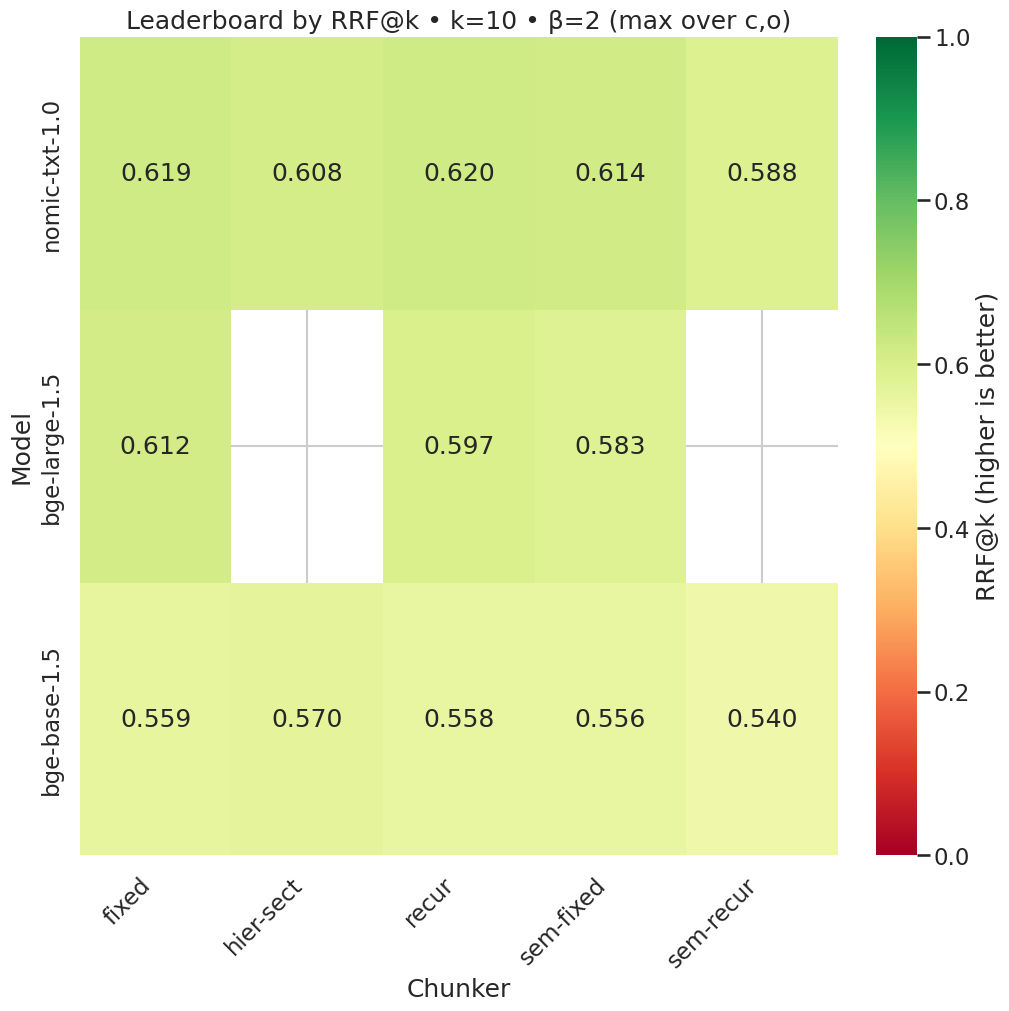

✅ Saved: fig_leaderboard_heatmap_rrf_beta_at_k.png | fig_leaderboard_heatmap_rrf_beta_at_k.pdf


In [40]:
# %%
# ---------- Leaderboard heatmap (max over c,o per model×chunker) ----------

metric_col = pick_metric(df)
df[metric_col] = _safe_num(df[metric_col])
if 'chunker' not in df.columns:
    df['chunker'] = 'unknown'
df['chunker'] = df['chunker'].fillna('unknown')
if 'model_short' not in df.columns and 'model_name' in df.columns:
    df['model_short'] = df['model_name'].astype(str).str.replace(r'[_\-]+', ' ', regex=True)

agg = (df.groupby(["model_short","chunker"], as_index=False)[metric_col]
         .max())

pivot = pd.pivot_table(agg, index="model_short", columns="chunker", values=metric_col, aggfunc="max")

if pivot.size == 0:
    print("No data for heatmap.")
else:
    # order rows by best score
    pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]

    # apply overrides + uniqueness
    full_models, full_chunkers = list(pivot.index), list(pivot.columns)
    model_abbrs = make_unique([MODEL_OVERRIDES.get(m, m) for m in full_models])
    chunk_abbrs = make_unique([CHUNKER_OVERRIDES.get(c, c) for c in full_chunkers])
    model_map = dict(zip(full_models, model_abbrs))
    chunk_map = dict(zip(full_chunkers, chunk_abbrs))

    pivot_disp = pivot.copy()
    pivot_disp.index = [model_map[m] for m in pivot.index]
    pivot_disp.columns = [chunk_map[c] for c in pivot.columns]

    fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
    sns.heatmap(
        pivot_disp, annot=True, fmt=".3f",
        cmap=HEATMAP_CMAP, vmin=0.0, vmax=1.0,
        ax=ax, cbar_kws={"label": f"{PRETTY.get(metric_col, metric_col)} (higher is better)"},
        mask=pivot_disp.isna()
    )
    ax.set_title(f"Leaderboard by {metric_title(df, metric_col)} (max over c,o)")
    ax.set_xlabel("Chunker")
    ax.set_ylabel("Model")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    plt.show()
    savefig(fig, f"fig_leaderboard_heatmap_{metric_col}")
    plt.close(fig)


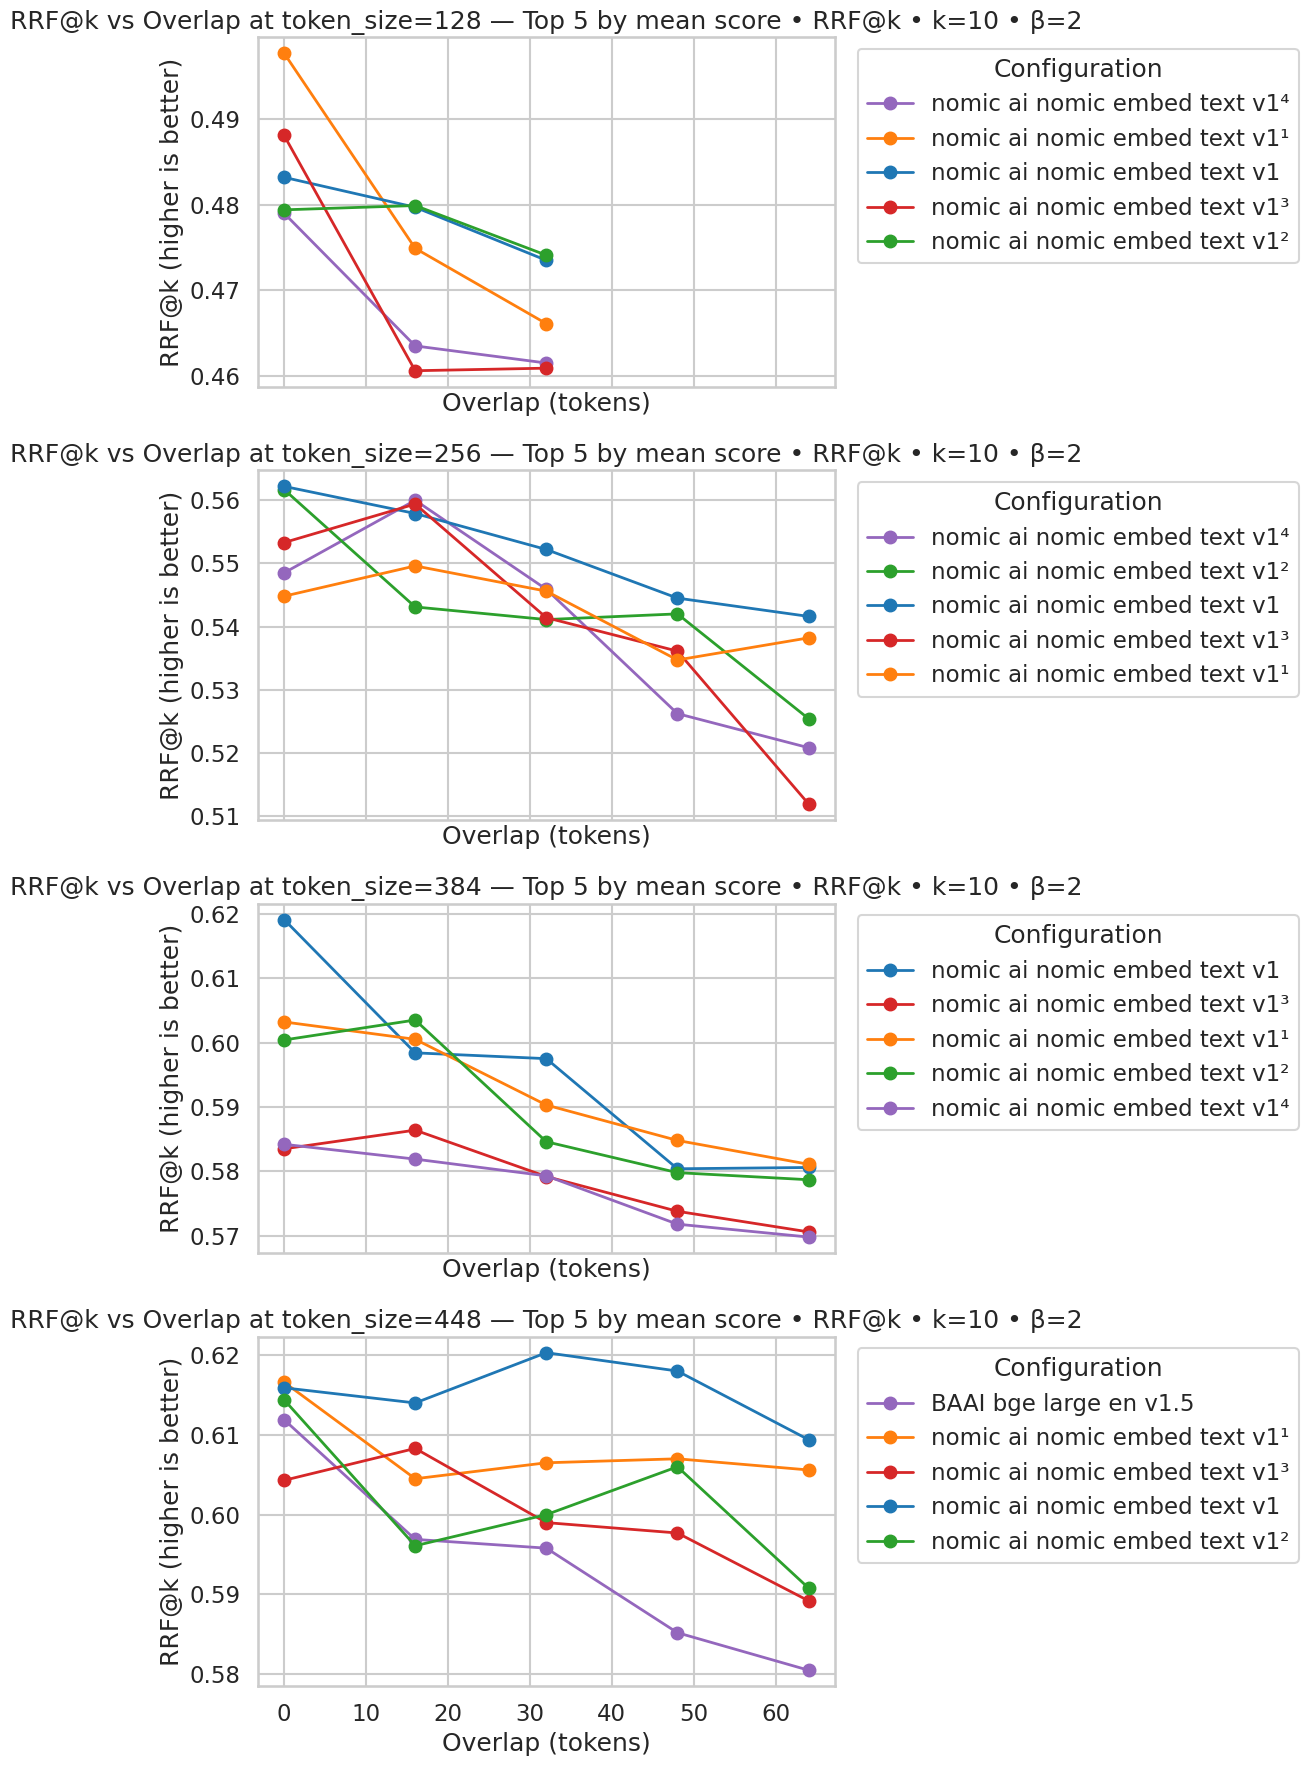

✅ Saved: fig_best_auc_overlap_rows_rrf_beta_at_k.png | fig_best_auc_overlap_rows_rrf_beta_at_k.pdf
✅ Saved combined leaderboard CSV (overlap).


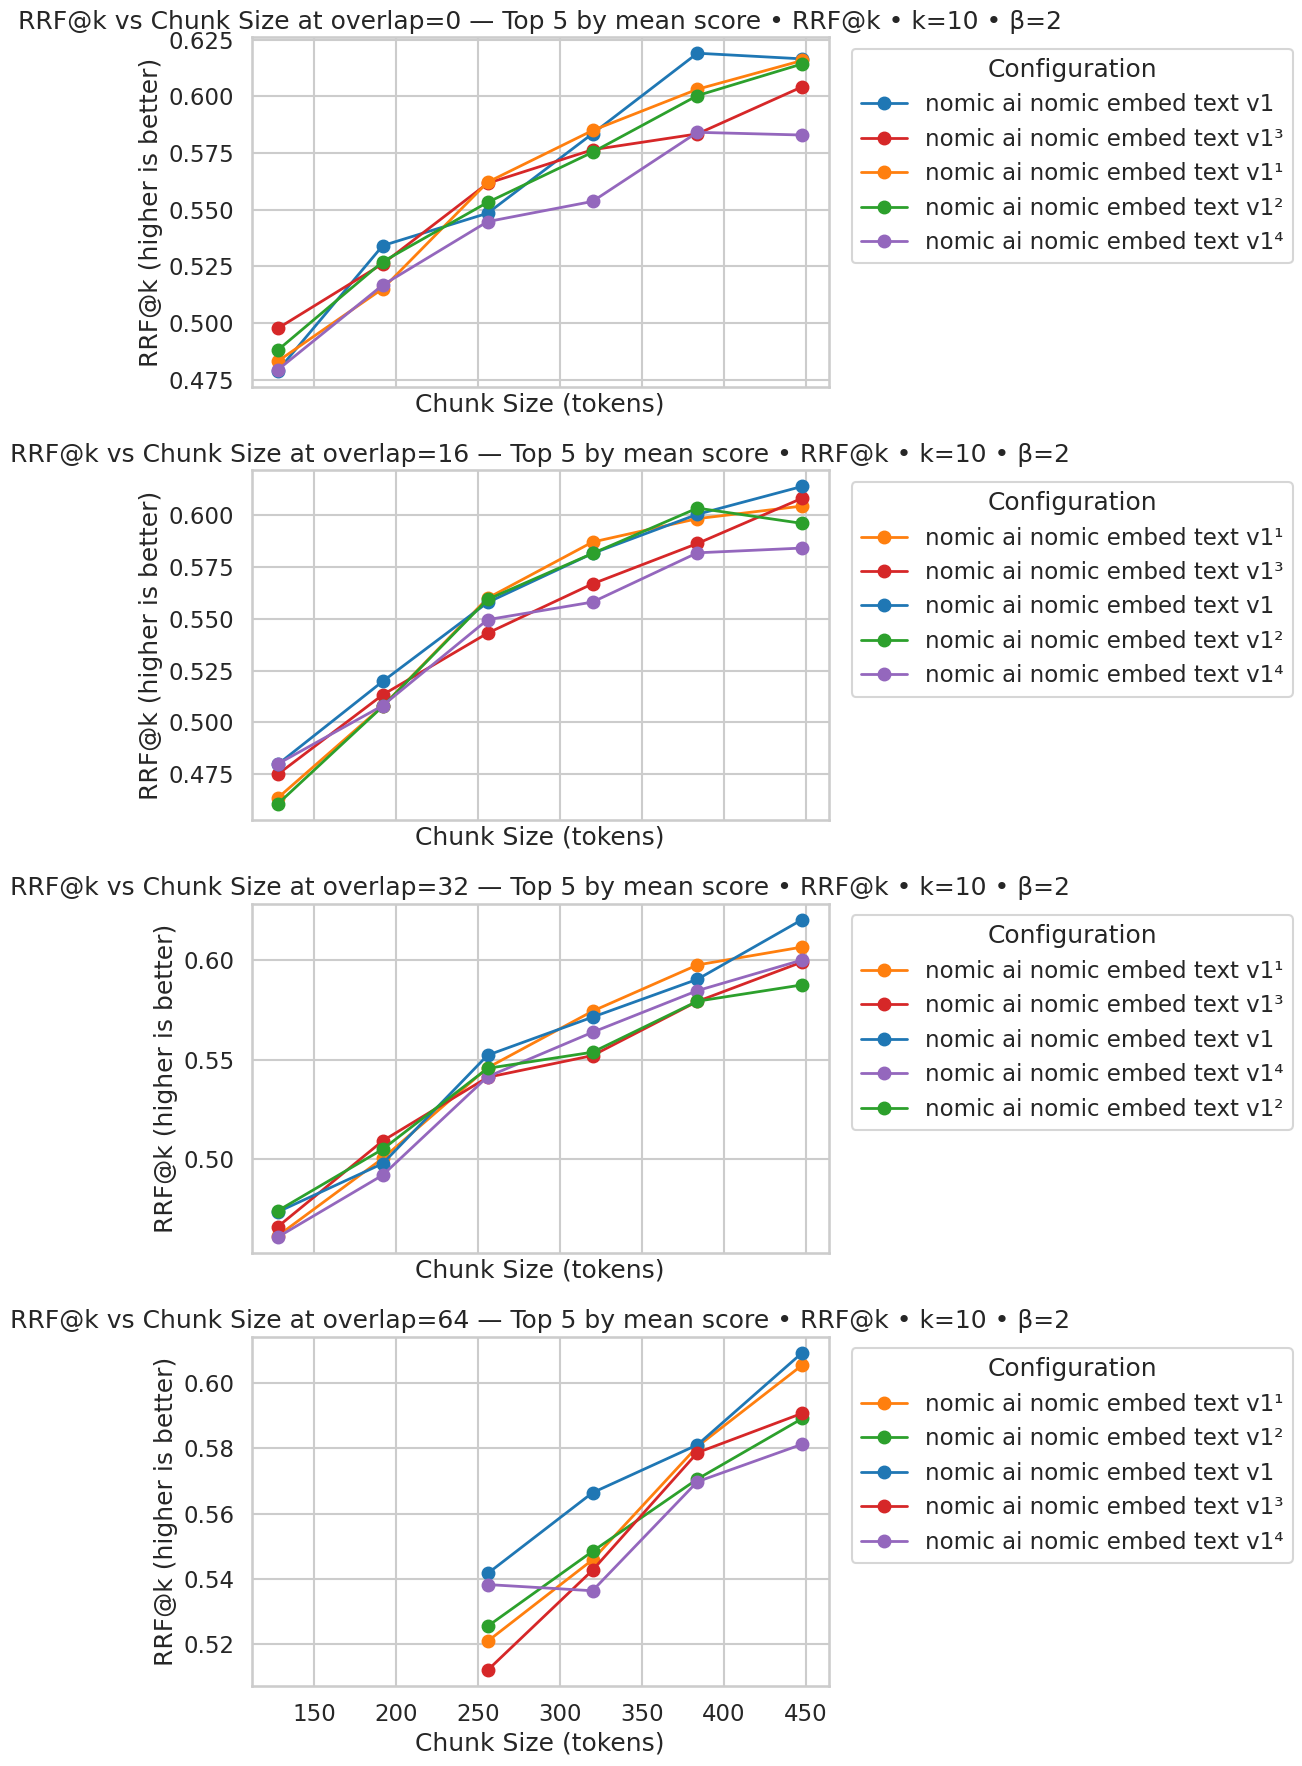

✅ Saved: fig_best_auc_chunksize_rows_rrf_beta_at_k.png | fig_best_auc_chunksize_rows_rrf_beta_at_k.pdf
✅ Saved combined leaderboard CSV (chunk size).


In [41]:
# %%
# ---------- Generic AUC plotter (overlap vs metric @ fixed c, and chunk size vs metric @ fixed o) ----------

_SUPERS = ['', '¹','²','³','⁴','⁵','⁶','⁷','⁸','⁹']
def _sup(n: int) -> str:
    if n<=0: return ''
    return _SUPERS[n] if n < len(_SUPERS) else f'^{n+1}'

def plot_auc_vs_param(df, fixed_col, fixed_values, x_col, metric_col, topn=TOPN_CURVES, title_left="", x_label=""):
    figs = []
    leaderboards = []

    fig, axes = plt.subplots(len(fixed_values), 1, figsize=(12, 18), sharex=True)
    if len(fixed_values) == 1: axes = [axes]

    for i, fixed_value in enumerate(fixed_values):
        ax = axes[i]
        sub = df[df.get(fixed_col, np.nan) == fixed_value].copy()
        if sub.empty:
            ax.set_title(f"{fixed_col}={fixed_value} (no data)")
            ax.set_xlabel(x_label)
            ax.set_ylabel(f"{PRETTY.get(metric_col, metric_col)} (higher is better)")
            continue

        if 'model_short' not in sub.columns:
            sub['model_short'] = sub.get('model_name', 'model')

        cols_needed = ['model_short','chunker', x_col, metric_col]
        sub = (sub[cols_needed]
                 .dropna()
                 .assign(**{x_col: _safe_num(sub[x_col]), metric_col: _safe_num(sub[metric_col])})
                 .dropna())
        sub = (sub.sort_values(['model_short','chunker', x_col, metric_col])
                  .groupby(['model_short','chunker', x_col], as_index=False)
                  .first())

        # AUC (normalized by span) per (model, chunker)
        rows = []
        for (m, ck), g in sub.groupby(['model_short','chunker']):
            g = g.sort_values(x_col)
            x, y = g[x_col].to_numpy(), g[metric_col].to_numpy()
            if len(x) < 2: continue
            span = float(x.max() - x.min())
            if span <= 0: continue
            auc = np.trapz(y, x)
            rows.append({'fixed': fixed_value, 'model_short': m, 'chunker': ck,
                         'auc': auc, 'norm_auc': auc/span, 'n_points': len(x)})
        auc_df = pd.DataFrame(rows).sort_values('norm_auc', ascending=False)
        if auc_df.empty:
            ax.set_title(f"{fixed_col}={fixed_value} (no AUC computed)")
            ax.set_xlabel(x_label); ax.set_ylabel(f"{PRETTY.get(metric_col, metric_col)} (higher is better)")
            continue

        winners = auc_df.head(min(topn, len(auc_df))).copy()
        leaderboards.append(winners)

        # keep only winners' curves
        keep = set(zip(winners['model_short'], winners['chunker']))
        plot_df = sub[sub.set_index(['model_short','chunker']).index.isin(keep)].copy()

        # model-only labels with superscripts for duplicates
        winners['occ'] = winners.groupby('model_short').cumcount()
        winners['legend_label'] = winners.apply(lambda r: f"{r['model_short']}{_sup(int(r['occ']))}", axis=1)
        label_map = {(r.model_short, r.chunker): r.legend_label for r in winners.itertuples(index=False)}
        plot_df['legend_label'] = plot_df.apply(lambda r: label_map[(r['model_short'], r['chunker'])], axis=1)

        # norm_auc for ordering & color
        plot_df = plot_df.merge(winners[['model_short','chunker','norm_auc']],
                                on=['model_short','chunker'], how='left')
        cfg_keys = plot_df[['model_short','chunker']].astype(str).agg('|'.join, axis=1)
        plot_df['cfg_id'] = cfg_keys
        cfg_order = (plot_df.groupby('cfg_id')['norm_auc'].first()
                     .sort_values(ascending=False).index.tolist())
        palette = sns.color_palette("tab10", n_colors=len(cfg_order))
        color_map = {cfg: palette[idx] for idx, cfg in enumerate(cfg_order)}

        # y-lims
        ymin, ymax = max(0.0, plot_df[metric_col].min()), min(1.0, plot_df[metric_col].max())
        pad = 0.05 * (ymax - ymin if ymax > ymin else 0.02)
        ax.set_ylim(max(0.0, ymin - pad), min(1.0, ymax + pad))

        # plot
        for cfg, g in plot_df.sort_values(['legend_label', x_col]).groupby('cfg_id'):
            ax.plot(g[x_col], g[metric_col], marker='o', linewidth=2,
                    color=color_map[cfg], label=g['legend_label'].iloc[0])

        ax.set_title(f"{title_left} at {fixed_col}={fixed_value} — Top {len(cfg_order)} by mean score • {metric_title(df, metric_col)}")
        ax.set_xlabel(x_label)
        ax.set_ylabel(f"{PRETTY.get(metric_col, metric_col)} (higher is better)")
        ax.legend(title="Configuration", bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout(); plt.show()
    return fig, pd.concat(leaderboards, ignore_index=True) if leaderboards else pd.DataFrame()

# Overlap curves at fixed chunk sizes
fig, leaders = plot_auc_vs_param(
    df, fixed_col='token_size', fixed_values=CHUNK_SIZES,
    x_col='overlap', metric_col=metric_col,
    title_left=f"{PRETTY.get(metric_col)} vs Overlap", x_label="Overlap (tokens)"
)
savefig(fig, f"fig_best_auc_overlap_rows_{metric_col}")
if not leaders.empty:
    leaders.to_csv(OUT_DIR / f"table_best_auc_overlap_multiC_rows_modelonly_{metric_col}.csv", index=False)
    print("✅ Saved combined leaderboard CSV (overlap).")

# Chunk-size curves at fixed overlaps
fig, leaders = plot_auc_vs_param(
    df, fixed_col='overlap', fixed_values=OVERLAPS,
    x_col='token_size', metric_col=metric_col,
    title_left=f"{PRETTY.get(metric_col)} vs Chunk Size", x_label="Chunk Size (tokens)"
)
savefig(fig, f"fig_best_auc_chunksize_rows_{metric_col}")
if not leaders.empty:
    leaders.to_csv(OUT_DIR / f"table_best_auc_chunksize_multiO_rows_modelonly_{metric_col}.csv", index=False)
    print("✅ Saved combined leaderboard CSV (chunk size).")
plt.close('all')


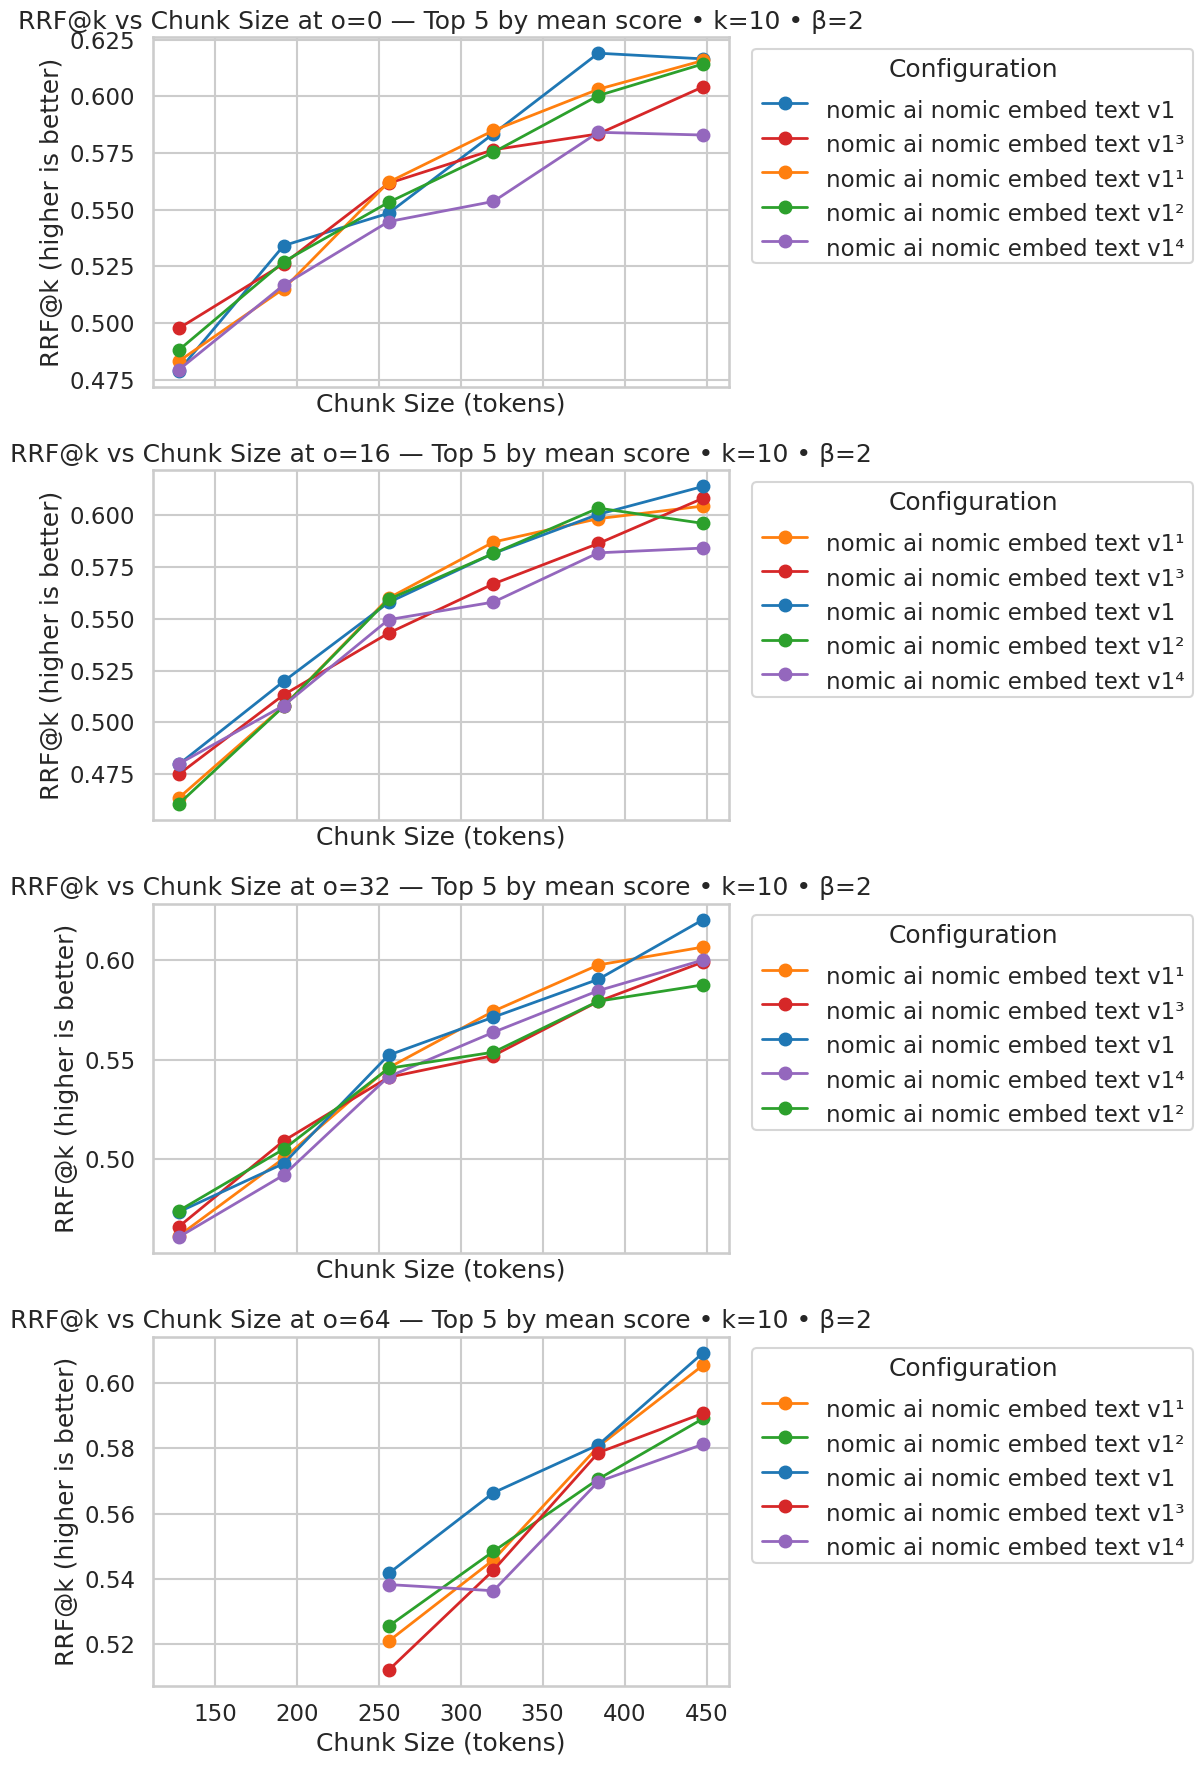

✅ Saved multi-subplot figure (o-wise) with model-only labels: fig_best_auc_chunksize_rows_rrf_beta_at_k.(png|pdf)
✅ Saved combined leaderboard CSV for rrf_beta_at_k.


In [ ]:
# %%
# ---------- Quality–Cost Pareto ----------

fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df, x='cost_norm', y=metric_col, hue='chunker', style='model_short', ax=ax, s=60)

mask = pareto_frontier(df, x='cost_norm', y=metric_col, minimize_x=True, maximize_y=True)
frontier = df.loc[mask].sort_values(['cost_norm', metric_col])
if not frontier.empty:
    ax.plot(frontier['cost_norm'], frontier[metric_col], color='black', linewidth=2, label='Pareto frontier')

ax.set_title(f"Quality–Cost Trade-off ({metric_title(df, metric_col)} vs Cost Norm)")
ax.set_xlabel("Cost Norm (relative chunk count)")
ax.set_ylabel(f"{PRETTY.get(metric_col, metric_col)} (higher is better)")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()
savefig(fig, f"fig_pareto_cost_{metric_col}")
plt.close(fig)


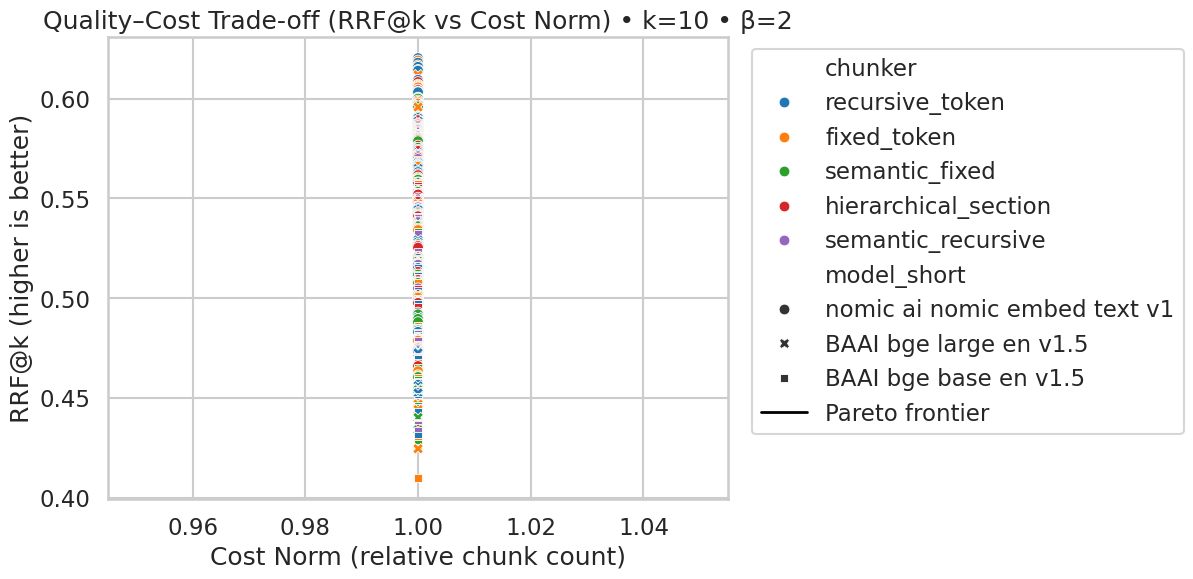

✅ Saved: figs/fig_pareto_cost_rrf_beta_at_k.(png|pdf)


In [42]:
# %%
# pick metric with fallback
metric_candidates = ["rrf_beta_at_k", "rrf_g_at_k", "ndcg_at_k"]
metric_col = next((m for m in metric_candidates if m in df.columns), None)
if metric_col is None:
    print("❌ Missing columns for Pareto plot. Run ensure_cols() first.")
else:
    fig, ax = plt.subplots(figsize=(8,6))
    sns.scatterplot(
        data=df, x='cost_norm', y=metric_col,
        hue='chunker', style='model_short', ax=ax, s=60
    )

    # pareto frontier: minimize x (cost), maximize y (score)
    mask = pareto_frontier(df, x='cost_norm', y=metric_col,
                           minimize_x=True, maximize_y=True)
    frontier = df.loc[mask].sort_values(['cost_norm', metric_col])
    if not frontier.empty:
        ax.plot(frontier['cost_norm'], frontier[metric_col],
                color='black', linewidth=2, label='Pareto frontier')

    # labels & title
    k_req = df.get("k_request")
    beta_v = df.get("beta")
    nice_name = {
        "rrf_beta_at_k": "RRF@k",
        "rrf_g_at_k": "RRF-G@k",
        "ndcg_at_k": "nDCG@k",
    }[metric_col]
    title_bits = [f"Quality–Cost Trade-off ({nice_name} vs Cost Norm)"]
    if isinstance(k_req, pd.Series) and not k_req.isna().all():
        title_bits.append(f"k={int(k_req.dropna().iloc[0])}")
    if metric_col == "rrf_beta_at_k" and isinstance(beta_v, pd.Series) and not beta_v.isna().all():
        try:
            title_bits.append(f"β={beta_v.dropna().iloc[0]:g}")
        except Exception:
            title_bits.append(f"β={beta_v.dropna().iloc[0]}")
    ax.set_title(" • ".join(title_bits))

    ax.set_xlabel("Cost Norm (relative chunk count)")
    ax.set_ylabel(f"{nice_name} (higher is better)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.show()
    fig.savefig(OUT_DIR / f"fig_pareto_cost_{metric_col}.png", bbox_inches='tight', dpi=300)
    fig.savefig(OUT_DIR / f"fig_pareto_cost_{metric_col}.pdf", bbox_inches='tight', dpi=300)
    plt.close(fig)
    print(f"✅ Saved: figs/fig_pareto_cost_{metric_col}.(png|pdf)")


In [ ]:
# %%
# ---------- Tail/global recall ratio vs nDCG ----------

# discover available recall@k and ndcg@k
recall_ks = sorted({int(m.group(1)) for c in df.columns if (m:=re.match(r"^recall_at_(\d+)$", c))})
ndcg_ks = sorted({int(m.group(1)) for c in df.columns if (m:=re.match(r"^ndcg_at_(\d+)$", c))})

if not ndcg_ks:
    print("No ndcg_at_* columns found — skipping plot.")
else:
    k_ndcg = min(ndcg_ks, key=lambda k: abs(k - 10))
    ndcg_col = f"ndcg_at_{k_ndcg}"

    if len(recall_ks) >= 2:
        k_small, k_large = recall_ks[0], recall_ks[-1]
        rec_small_col, rec_large_col = f"recall_at_{k_small}", f"recall_at_{k_large}"
        df_plot = df.copy()
        df_plot["ndcg_plot"] = _safe_num(df_plot[ndcg_col])
        df_plot["rec_small"] = _safe_num(df_plot[rec_small_col])
        df_plot["rec_large"] = _safe_num(df_plot[rec_large_col])
        df_plot["tail_recall_ratio"] = df_plot["rec_large"] / df_plot["rec_small"].replace(0, np.nan)
        df_plot = df_plot.replace([np.inf, -np.inf], np.nan).dropna(subset=["ndcg_plot","tail_recall_ratio"])

        if df_plot.empty:
            print("No finite points to plot — skipping scatter.")
        else:
            fig, ax = plt.subplots(figsize=(8,6))
            sns.scatterplot(data=df_plot, x="ndcg_plot", y="tail_recall_ratio", hue="chunker", style="model_short", ax=ax, s=60)
            ax.axhline(1.0, ls="--", color="grey", lw=1)
            ax.set_title(f"Tail vs Global Recall Ratio (R@{k_large}/R@{k_small}) vs nDCG@{k_ndcg}")
            ax.set_xlabel(f"nDCG@{k_ndcg} (higher is better)")
            ax.set_ylabel(f"Tail Recall Ratio (lower ≈ better)")
            ax.set_yscale("log")
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
            plt.show()
            savefig(fig, "fig_tailratio_vs_ndcg")
            plt.close(fig)

    elif len(recall_ks) == 1:
        k_rec = recall_ks[0]
        rec_col = f"recall_at_{k_rec}"
        df_plot = df.copy()
        df_plot["ndcg_plot"] = _safe_num(df_plot[ndcg_col])
        df_plot["rec_plot"] = _safe_num(df_plot[rec_col])
        df_plot = df_plot.dropna(subset=["ndcg_plot","rec_plot"])

        if df_plot.empty:
            print("No finite points to plot — skipping scatter.")
        else:
            fig, ax = plt.subplots(figsize=(8,6))
            sns.scatterplot(data=df_plot, x="ndcg_plot", y="rec_plot", hue="chunker", style="model_short", ax=ax, s=60)
            ax.set_title(f"Recall@{k_rec} vs nDCG@{k_ndcg}")
            ax.set_xlabel(f"nDCG@{k_ndcg} (higher is better)")
            ax.set_ylabel(f"Recall@{k_rec} (higher is better)")
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
            plt.show()
            savefig(fig, "fig_recall_vs_ndcg")
            plt.close(fig)
    else:
        print("No recall_at_* columns found — skipping plot.")


No finite points to plot — skipping scatter.


In [43]:
# %%
need = {'model_short','chunker','nauc_ndcg_at_10_max','nauc_ndcg_at_10_std'}
missing = need - set(df.columns)
if missing:
    print("Missing columns for robustness plot. Need:", need, "| Missing:", missing)
else:
    # choose metric to pick "best" per (model, chunker)
    metric_candidates = ["rrf_beta_at_k", "rrf_g_at_k", "ndcg_at_k"]
    metric_col = next((m for m in metric_candidates if m in df.columns), None)
    if metric_col is None:
        print(f"No score column among {metric_candidates}. Run ensure_cols() first.")
    else:
        subdf = df.copy()
        # ensure model_short exists
        if 'model_short' not in subdf.columns:
            subdf['model_short'] = subdf.get('model_name', 'model')

        # best (max score) per (model, chunker)
        best = (subdf.sort_values(metric_col, ascending=False)
                      .groupby(['model_short','chunker'], as_index=False)
                      .first())

        # keep rows with NAUC stats
        sub = best.dropna(subset=['nauc_ndcg_at_10_max','nauc_ndcg_at_10_std'])
        if sub.empty:
            print("No NAUC data after dropna.")
        else:
            # sort by robustness proxy: higher NAUC max first; tie-break by smaller std
            sub = sub.sort_values(['nauc_ndcg_at_10_max','nauc_ndcg_at_10_std'],
                                  ascending=[False, True])

            fig, ax = plt.subplots(figsize=(10,6))
            y = np.arange(len(sub))
            ax.barh(
                y,
                sub['nauc_ndcg_at_10_max'],
                xerr=0.5 * sub['nauc_ndcg_at_10_std'].abs(),
                color="#4c72b0",
                alpha=0.8
            )
            ax.set_yticks(y)
            ax.set_yticklabels([f"{m} · {c}" for m,c in zip(sub['model_short'], sub['chunker'])])
            ax.invert_yaxis()

            # Title / labels (include k/β if available)
            k_req = df.get("k_request")
            beta_v = df.get("beta")
            ttl = ["Robustness Across Test Items (NAUC nDCG@10)"]
            if isinstance(k_req, pd.Series) and not k_req.isna().all():
                ttl.append(f"k={int(k_req.dropna().iloc[0])}")
            if metric_col == "rrf_beta_at_k" and isinstance(beta_v, pd.Series) and not beta_v.isna().all():
                try:
                    ttl.append(f"β={beta_v.dropna().iloc[0]:g}")
                except Exception:
                    ttl.append(f"β={beta_v.dropna().iloc[0]}")
            ax.set_title(" • ".join(ttl))

            ax.set_xlabel("NAUC nDCG@10 (higher is better) ± 0.5×std")
            ax.set_ylabel("Model · Chunker")

            plt.show()
            fig.savefig(OUT_DIR / "fig_robustness_nauc.png", bbox_inches='tight', dpi=300)
            fig.savefig(OUT_DIR / "fig_robustness_nauc.pdf", bbox_inches='tight', dpi=300)
            plt.close(fig)
            print("✅ Saved: figs/fig_robustness_nauc.(png|pdf)")


Missing columns for robustness plot. Need: {'nauc_ndcg_at_10_std', 'nauc_ndcg_at_10_max', 'chunker', 'model_short'} | Missing: {'nauc_ndcg_at_10_std', 'nauc_ndcg_at_10_max'}


In [44]:
# %%
# ---------- Robustness / NAUC barh (if available) ----------

need = {'model_short','chunker','nauc_ndcg_at_10_max','nauc_ndcg_at_10_std'}
missing = need - set(df.columns)
if missing:
    print("Missing columns for robustness plot:", missing)
else:
    metric_col = pick_metric(df)
    subdf = df.copy()
    if 'model_short' not in subdf.columns:
        subdf['model_short'] = subdf.get('model_name', 'model')

    best = (subdf.sort_values(metric_col, ascending=False)
                 .groupby(['model_short','chunker'], as_index=False)
                 .first())

    sub = best.dropna(subset=['nauc_ndcg_at_10_max','nauc_ndcg_at_10_std'])
    if sub.empty:
        print("No NAUC data after dropna.")
    else:
        sub = sub.sort_values(['nauc_ndcg_at_10_max','nauc_ndcg_at_10_std'], ascending=[False, True])

        fig, ax = plt.subplots(figsize=(10,6))
        y = np.arange(len(sub))
        ax.barh(y, sub['nauc_ndcg_at_10_max'], xerr=0.5 * sub['nauc_ndcg_at_10_std'].abs(),
                color="#4c72b0", alpha=0.85)
        ax.set_yticks(y)
        ax.set_yticklabels([f"{m} · {c}" for m,c in zip(sub['model_short'], sub['chunker'])])
        ax.invert_yaxis()
        ax.set_title(f"Robustness Across Test Items (NAUC nDCG@10) • {metric_title(df, metric_col)}")
        ax.set_xlabel("NAUC nDCG@10 (higher is better) ± 0.5×std")
        ax.set_ylabel("Model · Chunker")
        plt.show()
        savefig(fig, "fig_robustness_nauc")
        plt.close(fig)


Missing columns for robustness plot: {'nauc_ndcg_at_10_std', 'nauc_ndcg_at_10_max'}


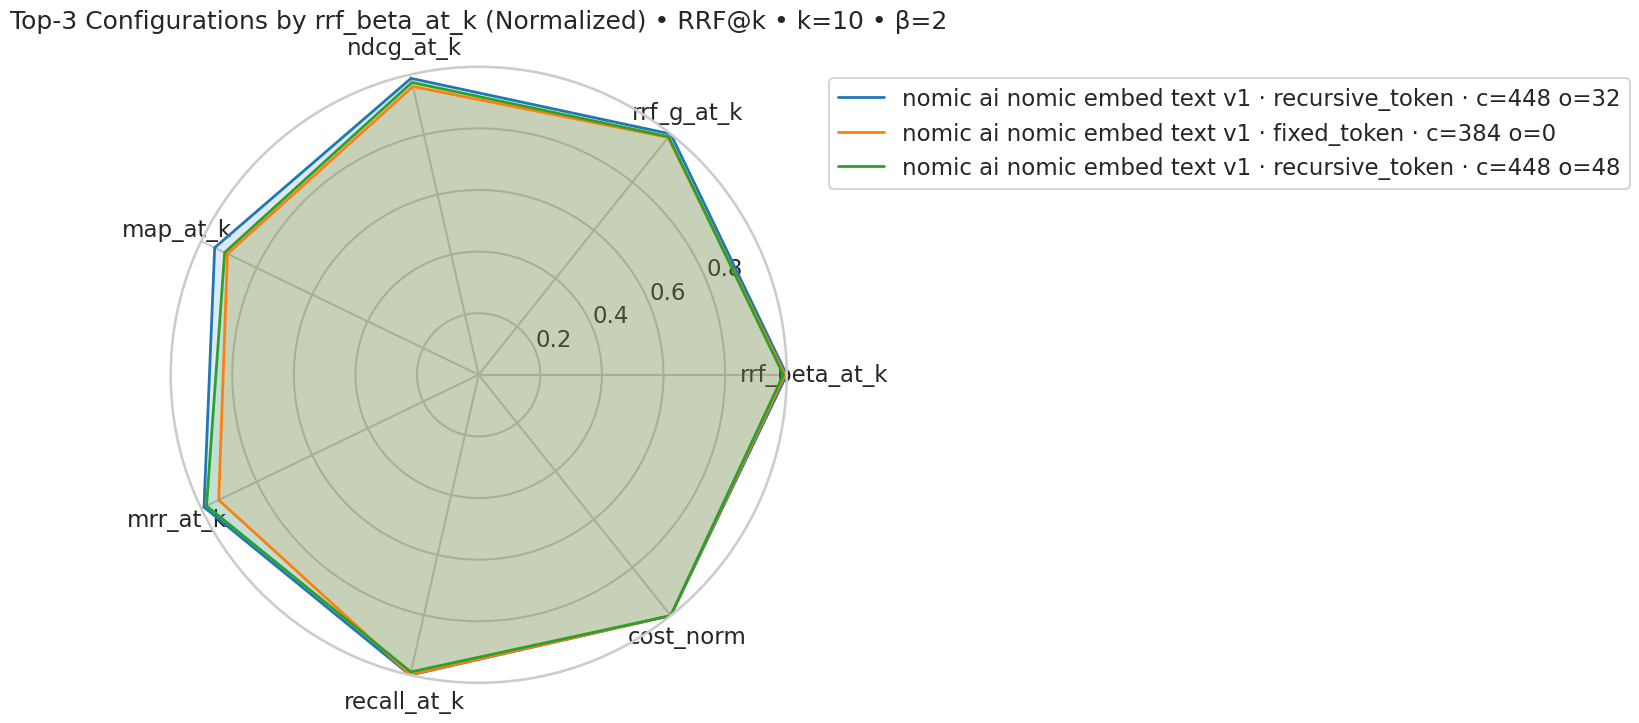

✅ Saved: fig_radar_top3.png | fig_radar_top3.pdf


In [45]:
# %%
# ---------- Radar: Top-3 by primary metric (normalized metrics) ----------

primary_candidates = ["rrf_beta_at_k", "rrf_g_at_k", "ndcg_at_k"]
primary_metric = pick_metric(df, primary_candidates)

metric_pool = [
    ("rrf_beta_at_k", True),
    ("rrf_g_at_k", True),
    ("ndcg_at_k", True),
    ("map_at_k", True),
    ("mrr_at_k", True),
    ("recall_at_k", True),
    ("precision_at_1", True),
    ("precision_at_10", True),
    ("cost_norm", False),
]
metrics = [(m, hb) for (m, hb) in metric_pool if m in df.columns]

sub = df.sort_values(primary_metric, ascending=False).head(3).copy()
if sub.empty:
    print("Not enough rows for radar.")
else:
    norm_vals, metric_names = [], []
    for name, higher_better in metrics:
        col = _safe_num(df[name])
        lo, hi = np.nanmin(col.values), np.nanmax(col.values)
        rng = hi - lo if (hi > lo) else 1.0
        vals = (_safe_num(sub[name]) - lo) / rng
        if not higher_better:
            vals = 1.0 - vals
        norm_vals.append(vals.fillna(0.5).values)
        metric_names.append(name)

    data = np.vstack(norm_vals)  # [num_metrics, topN]
    labels = [
        f"{row.get('model_short', row.get('model_name','?'))} · {row.get('chunker','?')} "
        f"· c={int(row.token_size) if pd.notna(row.get('token_size')) else '?'} "
        f"o={int(row.overlap) if pd.notna(row.get('overlap')) else '?'}"
        for _, row in sub.iterrows()
    ]

    angles = np.linspace(0, 2*np.pi, len(metric_names), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(8,8))
    ax = plt.subplot(111, polar=True)
    for i in range(len(sub)):
        vals = data[:, i].tolist(); vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=labels[i])
        ax.fill(angles, vals, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_names)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_ylim(0, 1)
    ax.set_title(f"Top-3 Configurations by {primary_metric} (Normalized) • {metric_title(df, primary_metric)}")
    ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    plt.show()
    savefig(fig, "fig_radar_top3")
    plt.close(fig)


In [48]:
from IPython.display import Markdown

def preview_latex(tex_str: str):
    display(Markdown(f"```latex\n{tex_str}\n```"))

In [49]:
# %%
# ---------- Leaderboard table (Top-K), CSV + LaTeX ----------

def topk_configs(df, k=20):
    key = 'rrf_beta_at_k' if 'rrf_beta_at_k' in df.columns else ('rrf_g_at_k' if 'rrf_g_at_k' in df.columns else 'ndcg_at_k')
    return df.sort_values(key, ascending=False).head(k).copy()

TOPK = 20
cols = [
    'model_short','chunker','token_size','overlap',
    'rrf_beta_at_k','rrf_g_at_k',
    'ndcg_at_k','map_at_k','mrr_at_k','recall_at_k',
    'precision_at_1','precision_at_10',
    'cost_norm',
    'k_request','k_recall_used','k_ndcg_used','k_map_used','k_mrr_used',
    'beta','alpha','gamma','delta',
]
cols_existing = [c for c in cols if c in df.columns]

sub = topk_configs(df, TOPK)[cols_existing].copy()
display(Markdown("**Top configurations (by single-score metric)**"))
display(sub.head(10))

csv_path = OUT_DIR / "table_leaderboard_topk_scores.csv"
sub.to_csv(csv_path, index=False)
print("✅ Saved CSV:", csv_path)

bold_candidates = (
    'rrf_beta_at_k','rrf_g_at_k','ndcg_at_k','map_at_k','mrr_at_k',
    'recall_at_k','precision_at_1','precision_at_10'
)
bold_cols = tuple(c for c in bold_candidates if c in sub.columns)

caption_bits = ["Top configurations by single-score retrieval metric (higher is better). Best per metric in bold."]
if 'k_request' in sub.columns and pd.notna(sub['k_request']).any():
    caption_bits.append(f"k={int(sub['k_request'].dropna().iloc[0])}")
if 'beta' in sub.columns and pd.notna(sub['beta']).any():
    try: caption_bits.append(f"β={sub['beta'].dropna().iloc[0]:g}")
    except Exception: caption_bits.append(f"β={sub['beta'].dropna().iloc[0]}")
caption = " • ".join(caption_bits)

tex = latex_table(
    sub.head(min(10, len(sub))),
    caption=caption,
    label="tab:leaderboard_scores",
    floatfmt="{:.3f}",
    bold_cols=bold_cols
)
tex_path = OUT_DIR / "table_leaderboard_top10_scores.tex"
tex_path.write_text(tex, encoding="utf-8")
print("✅ Saved LaTeX:", tex_path)
print("\nLaTeX preview:\n")
preview_latex(tex)


**Top configurations (by single-score metric)**

,model_short,chunker,token_size,overlap,rrf_beta_at_k,rrf_g_at_k,ndcg_at_k,map_at_k,mrr_at_k,recall_at_k,cost_norm,k_request,k_recall_used,k_ndcg_used,k_map_used,k_mrr_used,beta,alpha,gamma,delta
0,nomic ai nomic embed text v1,recursive_token,448,32,0.6203,0.5569,0.4536,0.3640,0.4280,0.6590,1.0,10,10,10,10,10,2.0,2.0,1.0,0.5
1,nomic ai nomic embed text v1,fixed_token,384,0,0.6191,0.5544,0.4498,0.3585,0.4222,0.6587,1.0,10,10,10,10,10,2.0,2.0,1.0,0.5
2,nomic ai nomic embed text v1,recursive_token,448,48,0.6180,0.5549,0.4517,0.3597,0.4270,0.6566,1.0,10,10,10,10,10,2.0,2.0,1.0,0.5
3,nomic ai nomic embed text v1,fixed_token,448,0,0.6166,0.5546,0.4554,0.3698,0.4263,0.6537,1.0,10,10,10,10,10,2.0,2.0,1.0,0.5
4,nomic ai nomic embed text v1,recursive_token,448,0,0.6159,0.5533,0.4487,0.3561,0.4283,0.6550,1.0,10,10,10,10,10,2.0,2.0,1.0,0.5
5,nomic ai nomic embed text v1,semantic_fixed,448,0,0.6144,0.5500,0.4465,0.3564,0.4182,0.6538,1.0,10,10,10,10,10,2.0,2.0,1.0,0.5
6,nomic ai nomic embed text v1,recursive_token,448,16,0.6140,0.5518,0.4500,0.3599,0.4256,0.6520,1.0,10,10,10,10,10,2.0,2.0,1.0,0.5
7,BAAI bge large en v1.5,fixed_token,448,0,0.6119,0.5468,0.4427,0.3534,0.4134,0.6518,1.0,10,10,10,10,10,2.0,2.0,1.0,0.5
8,nomic ai nomic embed text v1,recursive_token,448,64,0.6094,0.5469,0.4439,0.3508,0.4211,0.6481,1.0,10,10,10,10,10,2.0,2.0,1.0,0.5
9,nomic ai nomic embed text v1,hierarchical_section,448,16,0.6083,0.5448,0.4432,0.3550,0.4141,0.6469,1.0,10,10,10,10,10,2.0,2.0,1.0,0.5


✅ Saved CSV: ../artifacts/figs/table_leaderboard_topk_scores.csv


NameError: name 'tabular' is not defined

In [47]:
# %%
# ---------- Marginal means by model and chunker ----------

metric_col = pick_metric(df)

if 'model_short' in df.columns:
    by_model = (df.groupby('model_short')[metric_col]
                  .mean().reset_index()
                  .sort_values(metric_col, ascending=False))
    display(Markdown(f"**Marginal mean {PRETTY.get(metric_col)} by model (higher is better)**"))
    display(by_model)
    p = OUT_DIR / f"table_marginal_means_by_model_{metric_col}.csv"
    by_model.to_csv(p, index=False)
    print("✅ Saved:", p)

    tex1 = latex_table(
        by_model,
        caption=f"Marginal mean {PRETTY.get(metric_col)} by model (higher is better).",
        label=f"tab:marginal_model_{metric_col}",
        floatfmt="{:.3f}",
        bold_cols=(metric_col,)
    )
    (OUT_DIR / f"table_marginal_means_by_model_{metric_col}.tex").write_text(tex1, encoding="utf-8")
    print(f"✅ Saved LaTeX: table_marginal_means_by_model_{metric_col}.tex")
    print("\nLaTeX preview:\n"); print(tex1)
else:
    print("Missing 'model_short' for model marginal means.")

if 'chunker' in df.columns:
    by_chunker = (df.groupby('chunker')[metric_col]
                    .mean().reset_index()
                    .sort_values(metric_col, ascending=False))
    display(Markdown(f"**Marginal mean {PRETTY.get(metric_col)} by chunker (higher is better)**"))
    display(by_chunker)
    p = OUT_DIR / f"table_marginal_means_by_chunker_{metric_col}.csv"
    by_chunker.to_csv(p, index=False)
    print("✅ Saved:", p)

    tex2 = latex_table(
        by_chunker,
        caption=f"Marginal mean {PRETTY.get(metric_col)} by chunker (higher is better).",
        label=f"tab:marginal_chunker_{metric_col}",
        floatfmt="{:.3f}",
        bold_cols=(metric_col,)
    )
    (OUT_DIR / f"table_marginal_means_by_chunker_{metric_col}.tex").write_text(tex2, encoding="utf-8")
    print(f"✅ Saved LaTeX: table_marginal_means_by_chunker_{metric_col}.tex")
    print("\nLaTeX preview:\n"); print(tex2)
else:
    print("Missing 'chunker' for chunker marginal means.")


**Marginal mean RRF@k by model (higher is better)**

,model_short,rrf_beta_at_k
2,nomic ai nomic embed text v1,0.552837
1,BAAI bge large en v1.5,0.528989
0,BAAI bge base en v1.5,0.501764


✅ Saved: ../artifacts/figs/table_marginal_means_by_model_rrf_beta_at_k.csv


NameError: name 'tabular' is not defined